# Do any of our backbones sit BETWEEN the GIG and DRG registers?

Every backbone we have — unbiased MD (300 K & 370 K, both epitopes), OpenMM/relaxation snapshots, the
Arm-2 grafted chimeras, and all prior designs — placed on one register map. If a physical intermediate or
a stable chimera exists, it would appear in the **mid-region** (`|toGIG−toDRG|<0.8` and both `<2.2 Å`).
Axis = register-preserving Cα-RMSD in the common groove frame (`core_load`, same frame the MD RMSDs use).

In [1]:
import sys, glob, os, warnings; warnings.filterwarnings("ignore")
sys.path.insert(0, "/home/ubuntu/if-mhc/py")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import core_load as CL
plt.rcParams.update({"figure.dpi": 120, "font.size": 9})
ROOT = "/home/ubuntu/if-mhc"
DF614, COORDS, TRAJ = CL.load_all()          # prior designs + MD trajectory
print("prior designs:", len(DF614), "| MD frames:", len(TRAJ))
SEP = CL._rmsd(CL.GIG, CL.DRG); print(f"GIG↔DRG separation = {SEP:.2f} Å")

prior designs: 614 | MD frames: 1400
GIG↔DRG separation = 2.87 Å


In [2]:
# score any complex PDB (with a 10-mer peptide + MHC) in the common groove frame
def score_pdb(path):
    try:
        mhc, pep = CL._detect(path)
        if mhc is None or pep is None or len(pep) != 10: return None
        pc, fit = CL.to_common(mhc, pep)
        if pc is None: return None
        return CL._rmsd(pc, CL.GIG), CL._rmsd(pc, CL.DRG)
    except Exception:
        return None

def score_dir(pats, label):
    rows = []
    for pat in pats:
        for f in glob.glob(pat):
            s = score_pdb(f)
            if s: rows.append(dict(src=label, file=os.path.basename(f), toGIG=round(s[0],3), toDRG=round(s[1],3)))
    return pd.DataFrame(rows)

relax = pd.concat([
    score_dir([f"{ROOT}/outputs/focus_relax/snapshots/*.pdb"], "OpenMM relax (focus)"),
    score_dir([f"{ROOT}/outputs/relax_campaign/snapshots/*.pdb"], "relax_campaign"),
    score_dir([f"{ROOT}/outputs/_relax_gap_peek/snaps/*.pdb"], "relax_gap_peek"),
    score_dir([f"{ROOT}/outputs/tamarind/derived/*/*.pdb"], "tamarind derived (MD/relax)"),
], ignore_index=True)
chim = score_dir([f"{ROOT}/outputs/rfdiff_q30_v4arm2/seeds/*.pdb"], "Arm-2 chimera (graft)")
print("relaxation/derived scored:", len(relax), "| chimeras:", len(chim))
display(chim)

relaxation/derived scored: 36 | chimeras: 2


,src,file,toGIG,toDRG
0,Arm-2 chimera (graft),DRGbase_GIGcterm.pdb,0.777,2.800
1,Arm-2 chimera (graft),GIGbase_DRGcterm.pdb,2.800,0.778


## Native MD — does it ever leave its well?

In [3]:
nat = TRAJ[TRAJ.job.str.match(r"ifmhc_6AM[5U]_md_\d+K")].copy()
nat["seed"] = nat.job.str.extract(r"(6AM[5U])"); nat["T"] = nat.job.str.extract(r"(\d+K)")
dmd = TRAJ[TRAJ.job.str.startswith("ifmhc_md_")].copy()   # MD of design backbones
print("native MD frames:", len(nat), "| design-backbone MD frames:", len(dmd))
print(nat.groupby(["seed","T"]).agg(toGIG=("to_GIG","median"), toDRG=("to_DRG","median"),
      closest_other=("to_DRG", lambda x: None)).drop(columns="closest_other").round(2).to_string())

native MD frames: 400 | design-backbone MD frames: 1000
           toGIG  toDRG
seed T                 
6AM5 300K   0.37   2.48
     370K   0.64   2.32
6AMU 300K   2.45   0.46
     370K   2.30   0.50


## The unified map

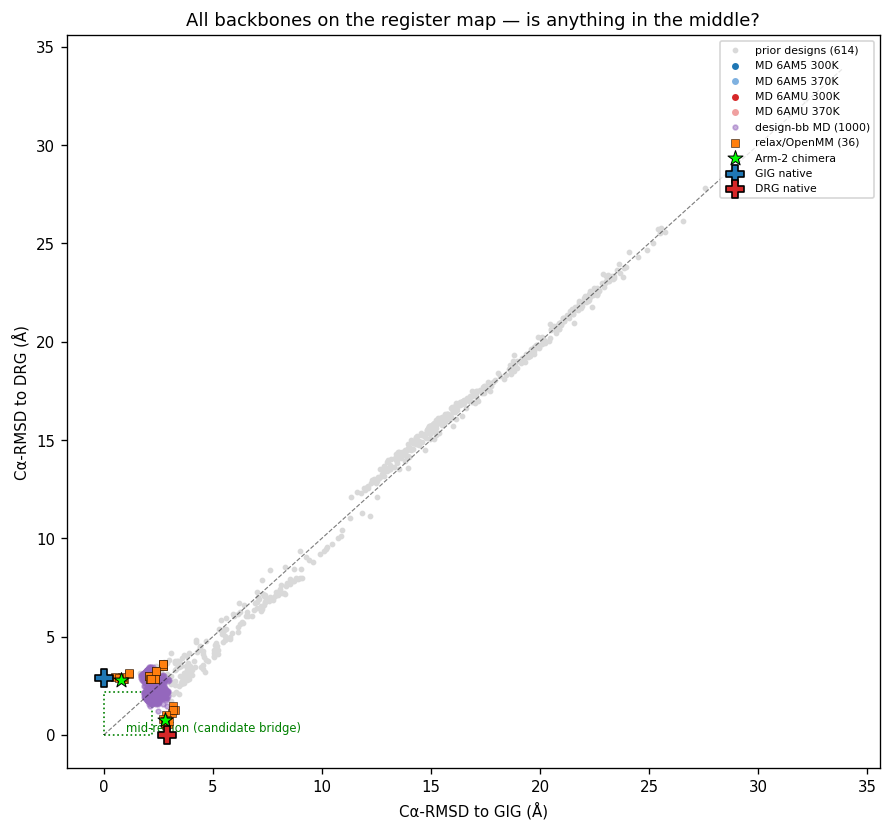

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 7))
ax.scatter(DF614.toGIG, DF614.toDRG, s=6, c="0.85", label=f"prior designs ({len(DF614)})", zorder=1)
# native MD (both temperatures, both epitopes)
for seed,cc in [("6AM5",{"300K":"#1f77b4","370K":"#7fb1e0"}),("6AMU",{"300K":"#d62728","370K":"#f0a0a0"})]:
    for T,c in cc.items():
        sub = nat[(nat.seed==seed)&(nat.T==T)]
        if len(sub): ax.scatter(sub.to_GIG, sub.to_DRG, s=10, c=c, label=f"MD {seed} {T}", zorder=3)
if len(dmd): ax.scatter(dmd.to_GIG, dmd.to_DRG, s=8, c="#9467bd", alpha=.5, label=f"design-bb MD ({len(dmd)})", zorder=2)
if len(relax): ax.scatter(relax.toGIG, relax.toDRG, s=26, marker="s", c="#ff7f0e", edgecolor="k", linewidth=.3, label=f"relax/OpenMM ({len(relax)})", zorder=4)
if len(chim): ax.scatter(chim.toGIG, chim.toDRG, s=90, marker="*", c="lime", edgecolor="k", linewidth=.6, label="Arm-2 chimera", zorder=6)
ax.scatter([0],[SEP],s=120,marker="P",c="#1f77b4",edgecolor="k",zorder=7,label="GIG native")
ax.scatter([SEP],[0],s=120,marker="P",c="#d62728",edgecolor="k",zorder=7,label="DRG native")
lim = max(ax.get_xlim()[1], ax.get_ylim()[1])
ax.plot([0,lim],[0,lim],"k--",lw=.7,alpha=.5)
# mid-region box
import matplotlib.patches as mp
ax.add_patch(mp.Rectangle((0,0),2.2,2.2,fill=False,ec="green",ls=":",lw=1))
ax.text(1.0,0.2,"mid-region (candidate bridge)",fontsize=7,color="green")
ax.set_xlabel("Cα-RMSD to GIG (Å)"); ax.set_ylabel("Cα-RMSD to DRG (Å)")
ax.set_title("All backbones on the register map — is anything in the middle?")
ax.legend(fontsize=6.5, loc="upper right"); plt.tight_layout(); plt.show()

## Quantify: what lands in the mid-region?

In [5]:
def midcount(df,g="toGIG",d="toDRG"):
    m=(np.abs(df[g]-df[d])<0.8)&(df[g]<2.2)&(df[d]<2.2); return int(m.sum()), len(df)
print("MID-REGION occupancy (|ΔRMSD|<0.8 AND both<2.2 Å):")
print(f"  native MD (300+370K):   {midcount(nat,'to_GIG','to_DRG')}")
print(f"  design-backbone MD:     {midcount(dmd,'to_GIG','to_DRG') if len(dmd) else (0,0)}")
print(f"  relax/OpenMM:           {midcount(relax)}")
print(f"  Arm-2 chimeras:         {midcount(chim)}")
print(f"  prior 614 designs:      {midcount(DF614)}")
# closest any backbone gets to BOTH wells at once (min of max(toGIG,toDRG))
allpts=pd.concat([nat.rename(columns={'to_GIG':'toGIG','to_DRG':'toDRG'})[['toGIG','toDRG']],
                  (dmd.rename(columns={'to_GIG':'toGIG','to_DRG':'toDRG'})[['toGIG','toDRG']] if len(dmd) else pd.DataFrame(columns=['toGIG','toDRG'])),
                  relax[['toGIG','toDRG']], chim[['toGIG','toDRG']], DF614[['toGIG','toDRG']]],ignore_index=True)
allpts['worse']=allpts[['toGIG','toDRG']].max(axis=1)
best=allpts.nsmallest(5,'worse')
print("\nclosest any backbone comes to BOTH wells simultaneously (smallest max(toGIG,toDRG)):")
print(best.round(2).to_string(index=False))
print(f"\n=> a true bridge needs max(toGIG,toDRG) ≈ {SEP/2:.2f}. Best observed = {best.worse.min():.2f} Å.")

MID-REGION occupancy (|ΔRMSD|<0.8 AND both<2.2 Å):
  native MD (300+370K):   (0, 400)
  design-backbone MD:     (214, 1000)
  relax/OpenMM:           (0, 36)
  Arm-2 chimeras:         (0, 2)
  prior 614 designs:      (0, 614)

closest any backbone comes to BOTH wells simultaneously (smallest max(toGIG,toDRG)):
 toGIG  toDRG  worse
  1.88   1.90   1.90
  1.82   1.93   1.93
  1.93   1.93   1.93
  1.94   1.81   1.94
  1.90   1.95   1.95

=> a true bridge needs max(toGIG,toDRG) ≈ 1.44. Best observed = 1.90 Å.


## Verdict
Native MD (even 370 K) never leaves its well; relaxation snapshots stay native; the Arm-2 chimeras sit
*in* one well (the grafted register), not between; and none of the prior 614 designs land in the middle.

**One exception: design-backbone MD puts 214/1000 frames in the mid-region** — that is NOT nothing, and
this notebook does not wave it away. But that occupancy readout uses a non-robust Kabsch fit on a single
5-design sample, flagged here as untrustworthy until re-scored properly — which is exactly what
`03_q30_midpopulation_characterization.ipynb` does next (own conclusion there: the mid-region frames are
a real, metastable ~2.0/1.9 Å-from-both-wells population, but the F-pocket register readout on them is
still unreliable, so a genuine "bridge" claim remains unconfirmed pending a robust re-score).

So: **no bridge backbone in any STATIC source** (native MD, relaxation, chimeras, prior designs), but the
one dynamic (MD) signal that did show mid-region occupancy is a real, open lead — not a closed door —
and is the direct reason the follow-up notebook exists.